# EDA

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.mixture import GaussianMixture
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.cluster import DBSCAN
from scipy import stats


In [2]:
master = pd.read_csv("data/master.csv")
complete = master[master["complete_window"] == True].copy()
recruiting = pd.read_csv("data/recruiting_clean.csv")
sp = pd.read_csv("data/sp_clean.csv")
records = pd.read_csv("data/records_clean.csv")
talent = pd.read_csv("data/talent_clean.csv")
coaches = pd.read_csv("data/coaches_clean.csv")
draft = pd.read_csv("data/draft_clean.csv")
draft_scored = pd.read_csv("data/draft_scored.csv")
lagged = pd.read_csv("data/lagged_df.csv")

In [3]:
master = pd.read_csv("data/master.csv")

# distributions
print("=== Distributions for key variables ===")
cols = ["rec_points", "draft_score_total", "development_residual", 
        "sp_rating", "win_pct"]
print(master[cols].describe().round(2))

# looking at draft score distributions
print("\n=== Draft score distribution ===")
print(f"Programs with 0 draft score: {(master['draft_score_total'] == 0).sum()}")
print(f"Programs with score > 100:   {(master['draft_score_total'] > 100).sum()}")
print(f"Programs with score > 200:   {(master['draft_score_total'] > 200).sum()}")
print(f"Median draft score: {master['draft_score_total'].median():.1f}")
print(f"Mean draft score:   {master['draft_score_total'].mean():.1f}")

# top and bottom developers
print("\n=== top 15 developers (highest average residual) ===")
top_dev = (master.groupby("team")["development_residual"]
           .agg(["mean", "count"])
           .query("count >= 5")
           .sort_values("mean", ascending=False)
           .head(15)
           .round(2))
print(top_dev)

print("\n=== bottom 15 developers (lowest average residual) ===")
bot_dev = (master.groupby("team")["development_residual"]
           .agg(["mean", "count"])
           .query("count >= 5")
           .sort_values("mean")
           .head(15)
           .round(2))
print(bot_dev)

# recruiting vs wins relationship
print("\n=== correlation with win percentage ===")
corr_cols = ["rec_points", "draft_score_total", "development_residual", 
             "sp_rating", "rec_rank"]
for col in corr_cols:
    corr = master[["win_pct", col]].dropna().corr().iloc[0, 1]
    print(f"  win_pct vs {col}: {corr:.3f}")

# does development predict wins?
print("\n=== correlations with SP ratnigs ===")
for col in ["rec_points", "draft_score_total", "development_residual"]:
    corr = master[["sp_rating", col]].dropna().corr().iloc[0, 1]
    print(f"  sp_rating vs {col}: {corr:.3f}")

# looking at overperformers and underperformers
print("\n=== top 10 single season overperformers ===")
print(master.nlargest(10, "development_residual")
      [["year", "team", "rec_points", "rec_rank", 
        "draft_score_total", "development_residual"]].to_string())

print("\n=== top 10 single season underperformers ===")
print(master.nsmallest(10, "development_residual")
      [["year", "team", "rec_points", "rec_rank",
        "draft_score_total", "development_residual"]].to_string())

# conference level patterns
print("\n=== average development residual by conference ===")
conf_dev = (master.groupby("conference")["development_residual"]
            .agg(["mean", "count"])
            .query("count >= 20")
            .sort_values("mean", ascending=False)
            .round(2))
print(conf_dev)

=== Distributions for key variables ===
       rec_points  draft_score_total  development_residual  sp_rating  win_pct
count     1875.00            1875.00               1875.00    1495.00  1496.00
mean       134.82              14.90                  0.00       1.66     0.52
std         78.97              19.84                 13.90      14.59     0.22
min         -0.11               0.00                -29.82     -38.90     0.00
25%         76.30               1.00                 -9.40      -9.40     0.33
50%        136.89               7.00                 -1.79       2.30     0.54
75%        192.02              21.00                  6.95      12.20     0.69
max        324.62             145.00                100.37      38.50     1.00

=== Draft score distribution ===
Programs with 0 draft score: 381
Programs with score > 100:   18
Programs with score > 200:   0
Median draft score: 7.0
Mean draft score:   14.9

=== top 15 developers (highest average residual) ===
                

First Notes:

- Finding 1: Recruiting explains only 39% of wins. Development residual adds an independent 26.9% of variation of wins.
- Finding 2: SEC development gap. The SEC has an average residual of +7.95 while every Group of 5 conference is negative
- Finding 3: Alabama's average residual is +65 and Ohio State's average residual is +43. Very large outliers
- Finding 5: The draft score data is extremely right skewed because 374 programs had 0 draft score in a given year

In [ ]:
# is the recruiting to draft relationship linear or curved
# bin recruiting points into deciles and see average draft score per bin
master["rec_decile"] = pd.qcut(master["rec_points"], q=10, labels=False)
print("=== draft score by recruiting devcile ===")
print(master.groupby("rec_decile")[["rec_points", "draft_score_total"]]
      .mean().round(2).to_string())

# development residual distribution
print("\n=== development recidual percentiles ===")
percentiles = [5, 10, 25, 50, 75, 90, 95]
for p in percentiles:
    val = np.percentile(master["development_residual"], p)
    print(f"  {p}th percentile: {val:.2f}")

# looking at tennessee
print("\n=== tennessee year by year ===")
print(master[master["team"] == "Tennessee"]
      [["year", "rec_rank", "rec_points", "draft_score_total", 
        "development_residual", "win_pct", "coach_name"]]
      .to_string())

# checking if alabama and LSU are true outliers from other top programs
print("\n=== residual distribution for top programs ===")
top_programs = ["Alabama", "Ohio State", "LSU", "Florida", 
                "Clemson", "USC", "Georgia"]
print(master[master["team"].isin(top_programs)]
      .groupby("team")["development_residual"]
      .describe().round(2).to_string())

=== draft score by recruiting devcile ===
            rec_points  draft_score_total
rec_decile                               
0                 9.13               1.39
1                32.63               1.90
2                74.88               4.12
3               104.70               5.01
4               125.56               7.26
5               148.39              10.87
6               169.57              14.63
7               192.46              21.74
8               219.65              28.40
9               271.22              53.58

=== development recidual percentiles ===
  5th percentile: -17.48
  10th percentile: -14.51
  25th percentile: -9.40
  50th percentile: -1.79
  75th percentile: 6.95
  90th percentile: 13.57
  95th percentile: 22.58

=== tennessee year by year ===
      year  rec_rank  rec_points  draft_score_total  development_residual   win_pct      coach_name
3     2005         4      276.14                 46              5.977379  0.454545  Phillip Fulmer
146  

The recruiting to draft relationship is exponential. The jump from residual 8 (average of 28) to decile 9 (average is 54) is very large. 

The residual distribution is right skewed. Median of -1.8 means most programs slightly underperform. 

### Correlation Matrix

                      rec_points  draft_score_total  development_residual  \
rec_points                 1.000              0.713                 0.008   
draft_score_total          0.713              1.000                 0.707   
development_residual       0.008              0.707                 1.000   
sp_rating                  0.716              0.625                 0.338   
win_pct                    0.399              0.406                 0.269   
first_round_total          0.556              0.879                 0.692   

                      sp_rating  win_pct  first_round_total  
rec_points                0.716    0.399              0.556  
draft_score_total         0.625    0.406              0.879  
development_residual      0.338    0.269              0.692  
sp_rating                 1.000    0.800              0.490  
win_pct                   0.800    1.000              0.330  
first_round_total         0.490    0.330              1.000  


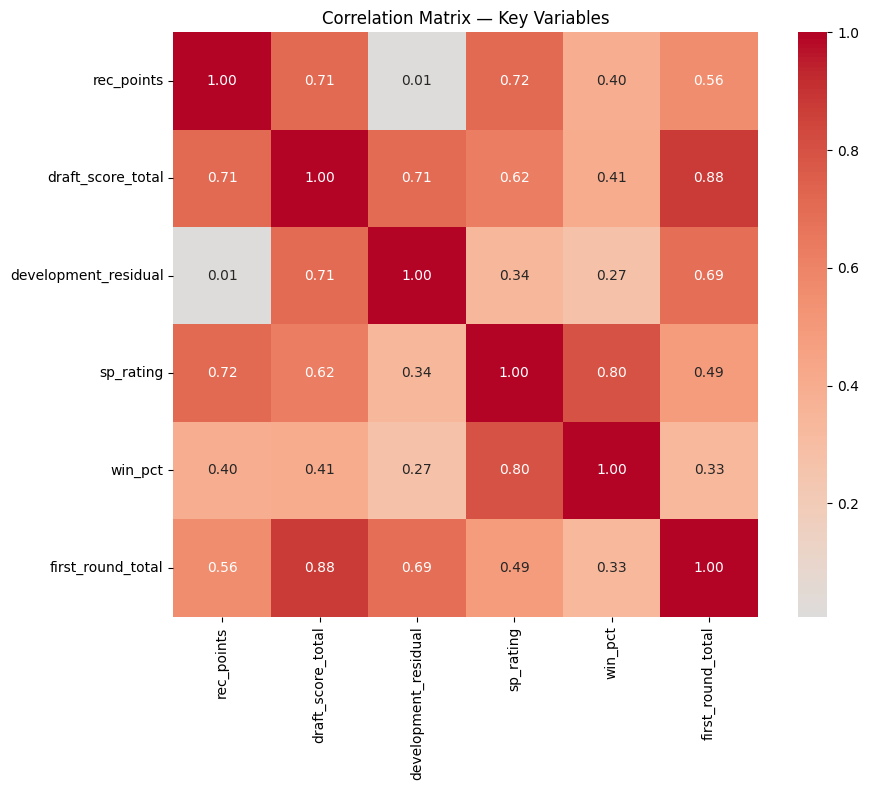

In [16]:
corr_cols = ["rec_points", "draft_score_total", "development_residual",
             "sp_rating", "win_pct", "first_round_total"]

corr_matrix = complete[corr_cols].corr().round(3)
print(corr_matrix)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True)
plt.title("Correlation Matrix — Key Variables")
plt.tight_layout()
plt.savefig
plt.show()

- development_residual vs rec_points = .01. Being near zero confirms that the residual is independent of recruiting
- rec_points vs win_pct = .40

### Quick Time Series Plots

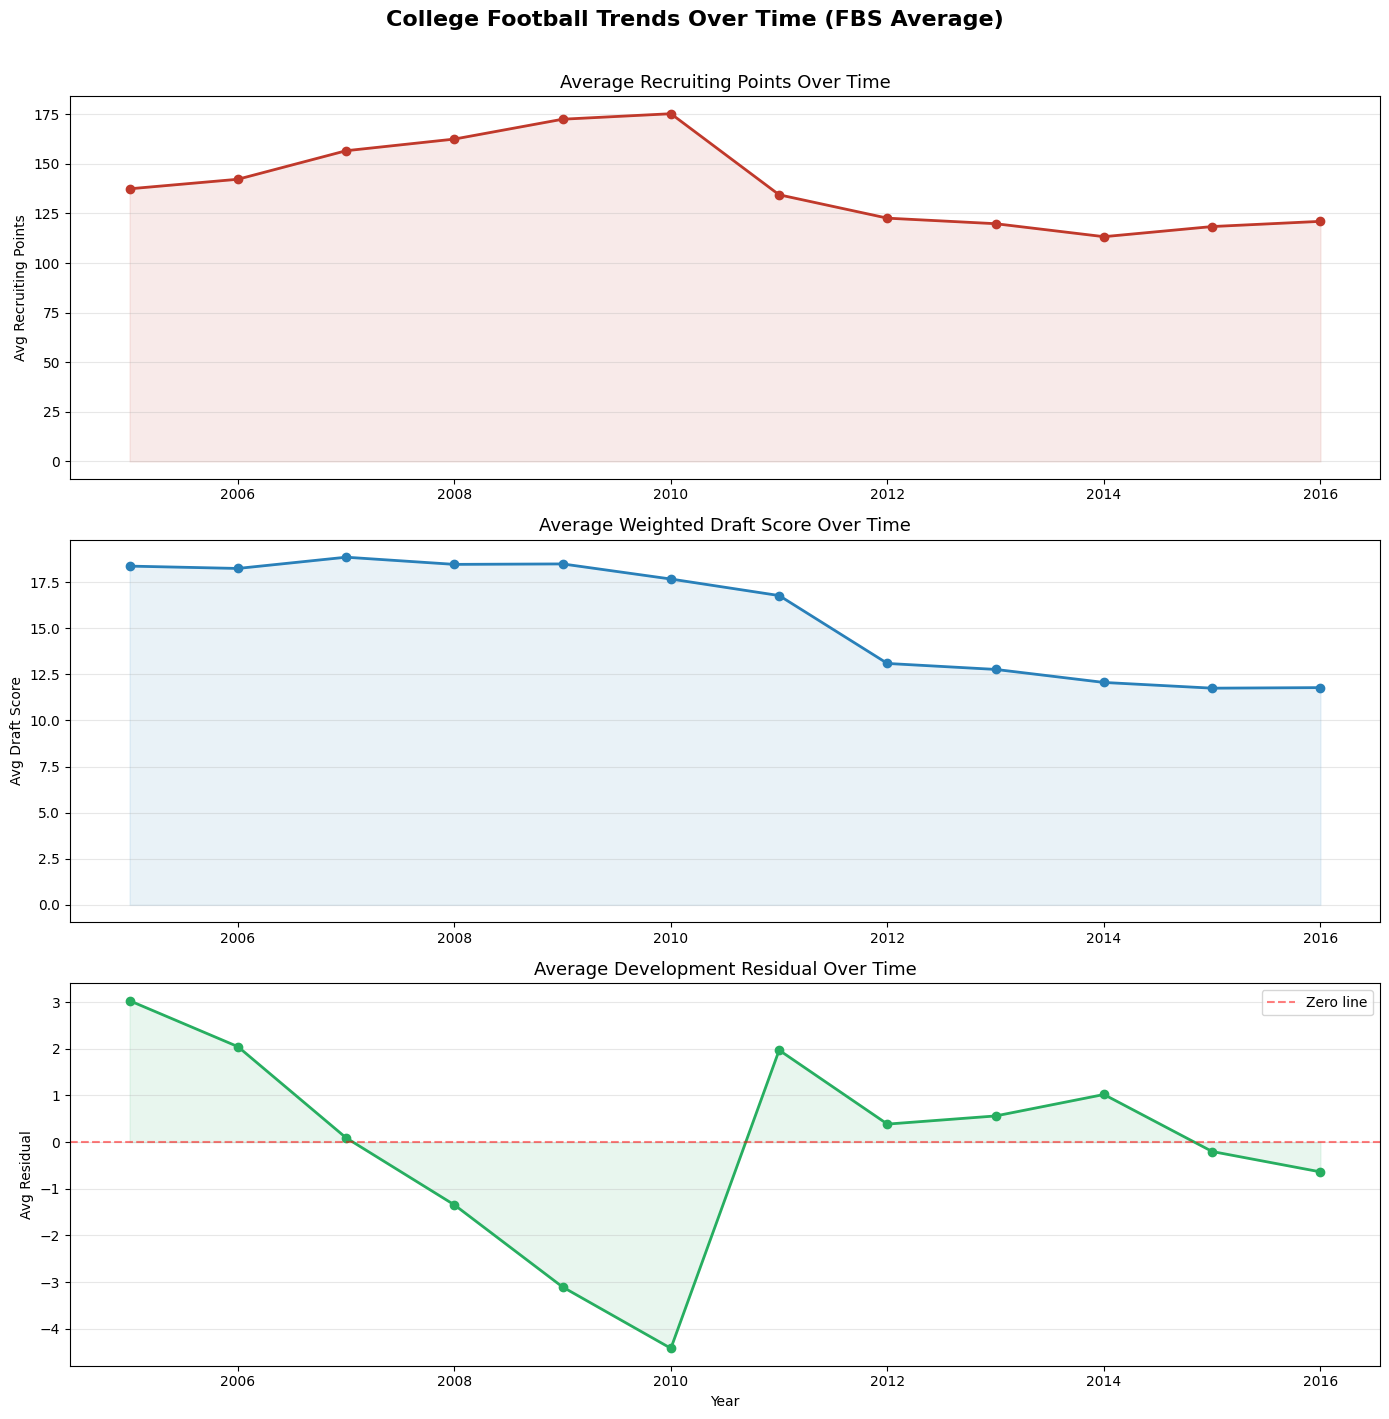

In [17]:

yearly = (complete.groupby("year")
          .agg(
              avg_rec_points=("rec_points", "mean"),
              avg_draft_score=("draft_score_total", "mean"),
              avg_dev_residual=("development_residual", "mean"),
              avg_win_pct=("win_pct", "mean"),
              avg_sp_rating=("sp_rating", "mean")
          ).reset_index())

fig, axes = plt.subplots(3, 1, figsize=(14, 14))
fig.suptitle("College Football Trends Over Time (FBS Average)", 
             fontsize=16, fontweight="bold", y=1.01)

axes[0].plot(yearly["year"], yearly["avg_rec_points"], 
             marker="o", linewidth=2, color="#c0392b", markersize=6)
axes[0].fill_between(yearly["year"], yearly["avg_rec_points"], 
                     alpha=0.1, color="#c0392b")
axes[0].set_title("Average Recruiting Points Over Time", fontsize=13)
axes[0].set_ylabel("Avg Recruiting Points")
axes[0].grid(axis="y", alpha=0.3)

axes[1].plot(yearly["year"], yearly["avg_draft_score"],
             marker="o", linewidth=2, color="#2980b9", markersize=6)
axes[1].fill_between(yearly["year"], yearly["avg_draft_score"],
                     alpha=0.1, color="#2980b9")
axes[1].set_title("Average Weighted Draft Score Over Time", fontsize=13)
axes[1].set_ylabel("Avg Draft Score")
axes[1].grid(axis="y", alpha=0.3)

axes[2].plot(yearly["year"], yearly["avg_dev_residual"],
             marker="o", linewidth=2, color="#27ae60", markersize=6)
axes[2].fill_between(yearly["year"], yearly["avg_dev_residual"],
                     alpha=0.1, color="#27ae60")
axes[2].axhline(y=0, color="red", linestyle="--", alpha=0.5, label="Zero line")
axes[2].set_title("Average Development Residual Over Time", fontsize=13)
axes[2].set_ylabel("Avg Residual")
axes[2].set_xlabel("Year")
axes[2].grid(axis="y", alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()

## Conference analysis

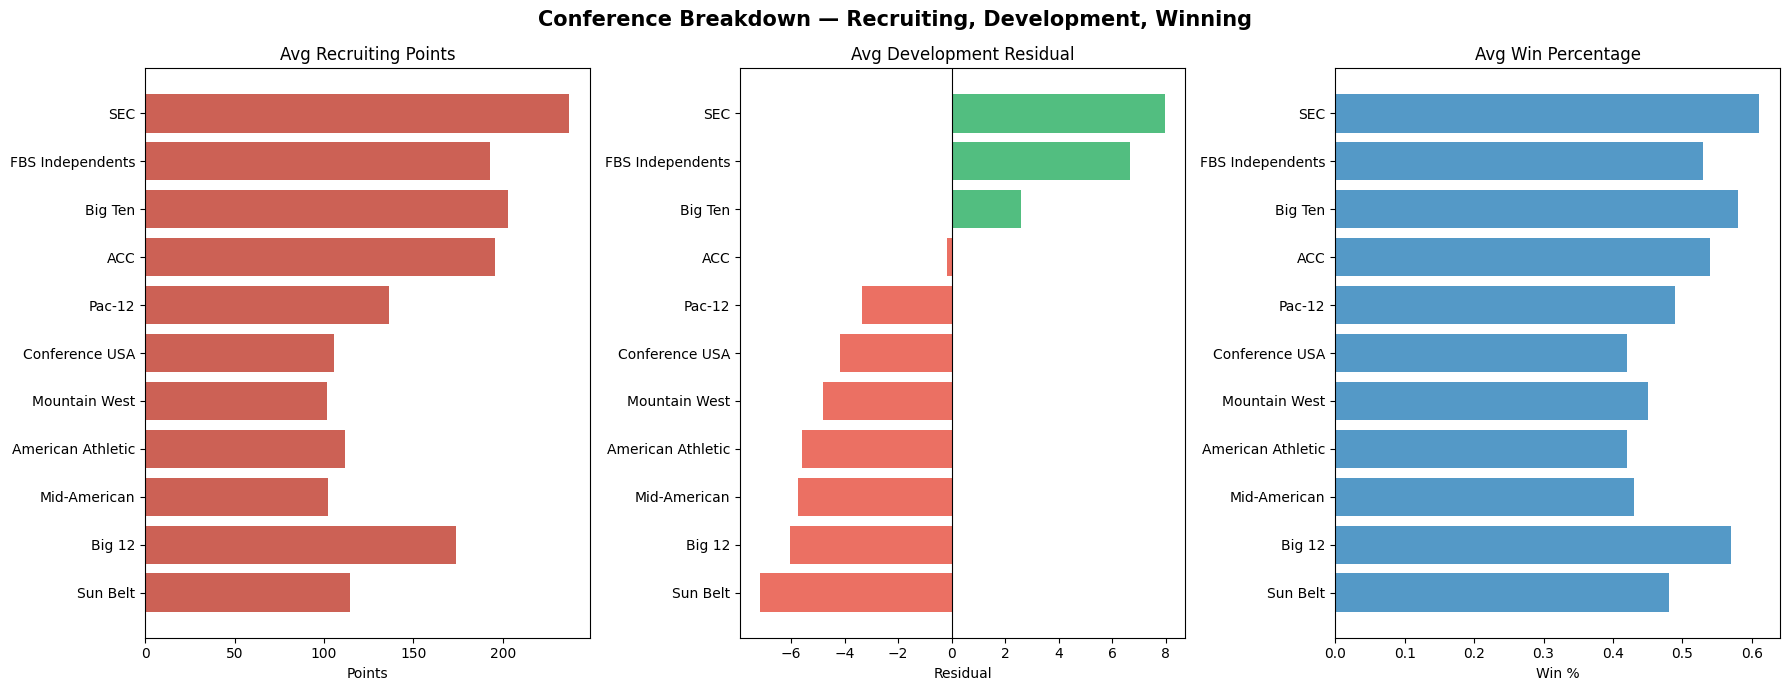

In [6]:
conf_analysis = (complete.groupby("conference")
                 .agg(
                     avg_rec_points=("rec_points", "mean"),
                     avg_draft_score=("draft_score_total", "mean"),
                     avg_dev_residual=("development_residual", "mean"),
                     avg_win_pct=("win_pct", "mean"),
                     n=("year", "count")
                 )
                 .query("n >= 20")
                 .sort_values("avg_dev_residual", ascending=False)
                 .round(2)
                 .reset_index())

fig, axes = plt.subplots(1, 3, figsize=(18, 7))
fig.suptitle("Conference Breakdown — Recruiting, Development, Winning",
             fontsize=15, fontweight="bold")

# average recruiting points by conference
axes[0].barh(conf_analysis["conference"], conf_analysis["avg_rec_points"],
             color="#c0392b", alpha=0.8)
axes[0].set_title("Avg Recruiting Points")
axes[0].set_xlabel("Points")
axes[0].invert_yaxis()

# average development residual by conference
colors = ["#27ae60" if x > 0 else "#e74c3c" 
          for x in conf_analysis["avg_dev_residual"]]
axes[1].barh(conf_analysis["conference"], conf_analysis["avg_dev_residual"],
             color=colors, alpha=0.8)
axes[1].axvline(x=0, color="black", linewidth=0.8)
axes[1].set_title("Avg Development Residual")
axes[1].set_xlabel("Residual")
axes[1].invert_yaxis()

# average win percentage by conference
axes[2].barh(conf_analysis["conference"], conf_analysis["avg_win_pct"],
             color="#2980b9", alpha=0.8)
axes[2].set_title("Avg Win Percentage")
axes[2].set_xlabel("Win %")
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()

## Exploratory scatterplots

- SEC: They are recruiting better than any conference, and develop their players at the best rate
- Big 12: they recruit well (4th in recruiting points), but have the second worst development residual, but they still have a high win %

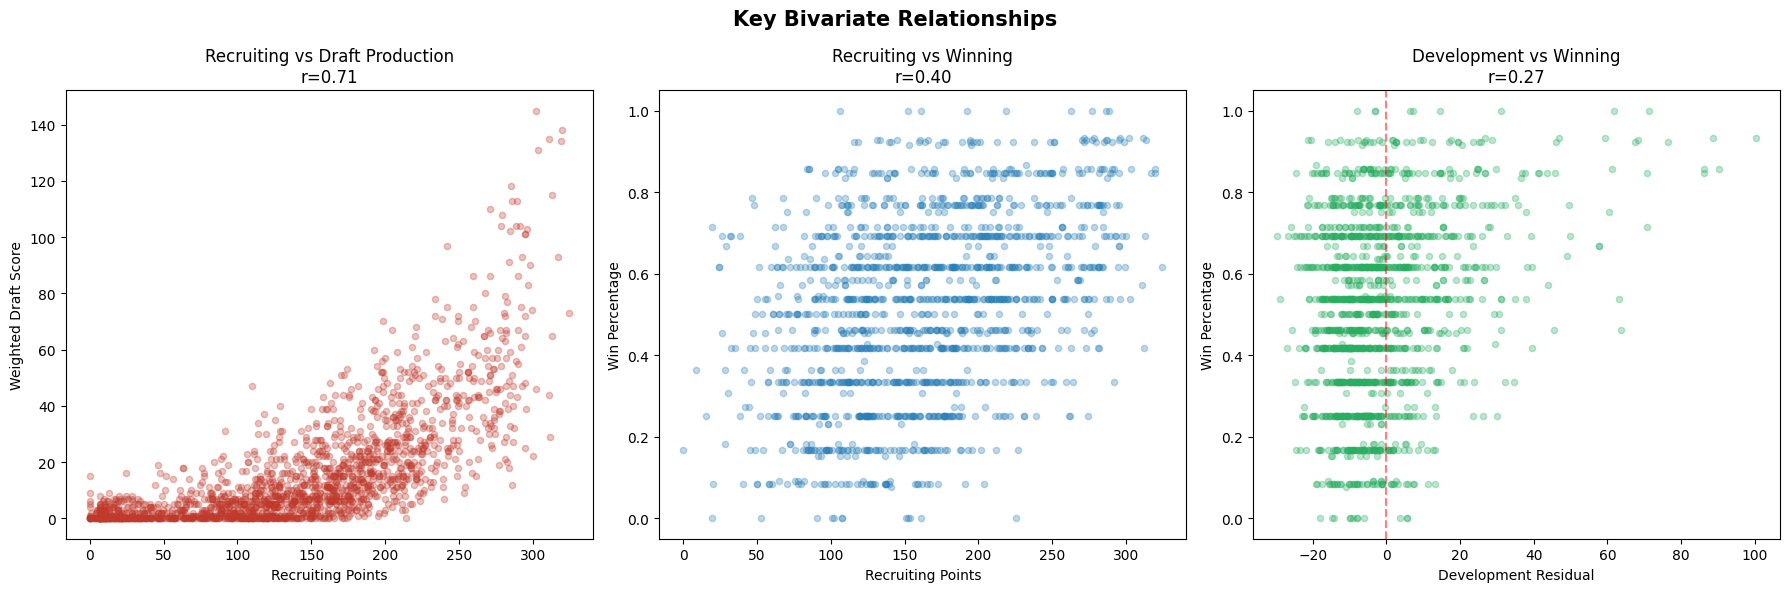

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Key Bivariate Relationships", fontsize=15, fontweight="bold")

# recruiting vs draft score
axes[0].scatter(complete["rec_points"], complete["draft_score_total"],
                alpha=0.3, s=20, color="#c0392b")
axes[0].set_xlabel("Recruiting Points")
axes[0].set_ylabel("Weighted Draft Score")
axes[0].set_title("Recruiting vs Draft Production\nr=0.71")

# recruiting vs win pct
axes[1].scatter(complete["rec_points"], complete["win_pct"],
                alpha=0.3, s=20, color="#2980b9")
axes[1].set_xlabel("Recruiting Points")
axes[1].set_ylabel("Win Percentage")
axes[1].set_title("Recruiting vs Winning\nr=0.40")

# development residual vs win pct
axes[2].scatter(complete["development_residual"], complete["win_pct"],
                alpha=0.3, s=20, color="#27ae60")
axes[2].axvline(x=0, color="red", linestyle="--", alpha=0.5)
axes[2].set_xlabel("Development Residual")
axes[2].set_ylabel("Win Percentage")
axes[2].set_title("Development vs Winning\nr=0.27")

plt.tight_layout()
plt.show()

- Clear positive relationship between recruiting and draft production. 
- Recruiting vs winning is weak and noisy. Lots of low recruiting programs winning 60-70% of games, and high recruiting programs losing frequently.
- Development vs winning: The programs with very negative residuals are spread across all win percentages. Appears like you can win without developing NFL talent

### Outlier Identification

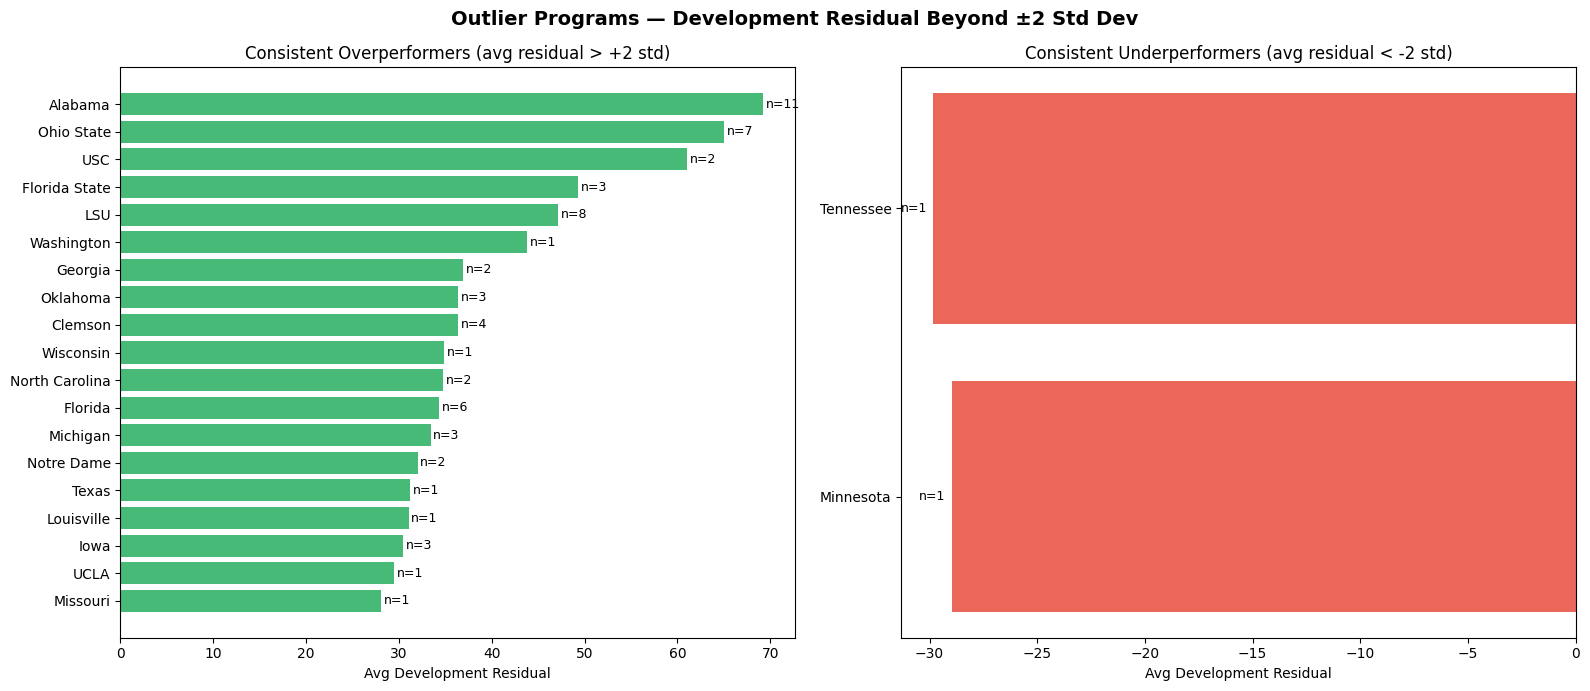

In [8]:
mean_res = complete["development_residual"].mean()
std_res = complete["development_residual"].std()
threshold = 2 * std_res

outliers_high = (complete[complete["development_residual"] > mean_res + threshold]
                 .groupby("team")["development_residual"]
                 .agg(["mean", "count"])
                 .sort_values("mean", ascending=False)
                 .reset_index())

outliers_low = (complete[complete["development_residual"] < mean_res - threshold]
                .groupby("team")["development_residual"]
                .agg(["mean", "count"])
                .sort_values("mean")
                .reset_index())

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Outlier Programs — Development Residual Beyond ±2 Std Dev",
             fontsize=14, fontweight="bold")

# Top overperformers
axes[0].barh(outliers_high["team"], outliers_high["mean"],
             color="#27ae60", alpha=0.85)
axes[0].set_title("Consistent Overperformers (avg residual > +2 std)")
axes[0].set_xlabel("Avg Development Residual")
axes[0].invert_yaxis()
for i, (val, cnt) in enumerate(zip(outliers_high["mean"], outliers_high["count"])):
    axes[0].text(val + 0.3, i, f"n={cnt}", va="center", fontsize=9)

# Top underperformers
axes[1].barh(outliers_low["team"], outliers_low["mean"],
             color="#e74c3c", alpha=0.85)
axes[1].set_title("Consistent Underperformers (avg residual < -2 std)")
axes[1].set_xlabel("Avg Development Residual")
axes[1].invert_yaxis()
for i, (val, cnt) in enumerate(zip(outliers_low["mean"], outliers_low["count"])):
    axes[1].text(val - 0.3, i, f"n={cnt}", va="center", ha="right", fontsize=9)

plt.tight_layout()
plt.show()

### VIF

In [ ]:
vif_data = complete[["rec_points", "sp_rating", 
                      "win_pct", "draft_score_total",
                      "development_residual"]].dropna()

vif_results = pd.DataFrame()
vif_results["feature"] = vif_data.columns
vif_results["VIF"] = [
    variance_inflation_factor(vif_data.values, i) 
    for i in range(vif_data.shape[1])
]
print(vif_results.round(2).to_string())

                feature     VIF
0            rec_points  404.41
1             sp_rating    5.94
2               win_pct    3.38
3     draft_score_total  447.86
4  development_residual  134.84


Going to try to drop draft score total and sp rating to see if that lowers VIF of the remaining features. These two features are already captured by the others

In [10]:
vif_data = complete[["rec_points", "development_residual", "win_pct"]].dropna()

vif_results = pd.DataFrame()
vif_results["feature"] = vif_data.columns
vif_results["VIF"] = [
    variance_inflation_factor(vif_data.values, i) 
    for i in range(vif_data.shape[1])
]
print(vif_results.round(2).to_string())

                feature   VIF
0            rec_points  6.12
1  development_residual  1.00
2               win_pct  6.12


### Trying to see what typically comes first among: wins, recruits, or draft results

In [16]:
results = []

for team, group in complete.groupby("team"):
    group = group.sort_values("year").reset_index(drop=True)
    
    if len(group) < 7:
        continue
    
    for lag in [1, 2, 3]:
        # recruiting to winning
        rec_leads_win = group["rec_points"].corr(
            group["win_pct"].shift(-lag))
        
        # Winning to Recruiting
        win_leads_rec = group["win_pct"].corr(
            group["rec_points"].shift(-lag))
        
        # Recruiting to Draft
        rec_leads_draft = group["rec_points"].corr(
            group["draft_score_total"].shift(-lag))
        
        # Draft to Recruiting
        draft_leads_rec = group["draft_score_total"].corr(
            group["rec_points"].shift(-lag))
        
        # Winning to Draft
        win_leads_draft = group["win_pct"].corr(
            group["draft_score_total"].shift(-lag))
        
        # Draft to Winning
        draft_leads_win = group["draft_score_total"].corr(
            group["win_pct"].shift(-lag))
        
        results.append({
            "team": team,
            "lag": lag,
            "rec_leads_win": rec_leads_win,
            "win_leads_rec": win_leads_rec,
            "rec_leads_draft": rec_leads_draft,
            "draft_leads_rec": draft_leads_rec,
            "win_leads_draft": win_leads_draft,
            "draft_leads_win": draft_leads_win
        })

lag_df = pd.DataFrame(results)

print("average lag correlations across all fbs programs")
avg_lags = (lag_df.groupby("lag")
            [["rec_leads_win", "win_leads_rec",
              "rec_leads_draft", "draft_leads_rec",
              "win_leads_draft", "draft_leads_win"]]
            .mean().round(3))
print(avg_lags.to_string())

average lag correlations across all fbs programs
     rec_leads_win  win_leads_rec  rec_leads_draft  draft_leads_rec  win_leads_draft  draft_leads_win
lag                                                                                                  
1            0.045          0.128            0.013            0.086           -0.073            0.133
2            0.042          0.128           -0.043            0.028           -0.085            0.332
3           -0.007          0.063           -0.039            0.013           -0.050            0.335


/opt/miniconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/miniconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


- Clearest pattern: draft production leads to future winning (.332 at lag 2 and .335 at lag 3). Programs that produce NFL talent see their winning improve 2-3 years later.
- Winning leads future recruitment (0.128 at lag 1 and 2). Winning leads to getting better recruits
- Recruiting does not lead winning or draft production. rec_leads_wins and rec_leads draft are near zero or negative across all lags.

Building the narrative: Develop players into NFL talent, and the wins follow 2-3 years later. Recruiting is largerly a lagging indicator, not a leading one

Hierarchy of what predicts future winning:

- draft leads wins at lag 2-3: 0.332-0.335
- dev leads win at lag 2-3: 0.265-0.280
- win leads recruits: at lag 1-2: 0.128
- rec leads wins: at all lags roughly .04 (nearly 0)

#### Looking at programs that began losing

In [20]:
print("=== top 10: winning leads to draft decline (lag=2) ===")
print(lag_df[lag_df["lag"]==2]
      .nsmallest(10, "win_leads_draft")
      [["team", "win_leads_draft", "draft_leads_win",
        "win_leads_rec", "rec_leads_win"]]
      .round(3).to_string())

print()
print("=== top 10: recruiting leads to win decline(lag=2) ===")
print(lag_df[lag_df["lag"]==2]
      .nsmallest(10, "rec_leads_win")
      [["team", "rec_leads_win", "win_leads_rec",
        "draft_leads_win", "dev_leads_win"]]
      .round(3).to_string())

print()
print("=== top 10: draft decline leads to recruiting decline (lag=2) ===")
print(lag_df[lag_df["lag"]==2]
      .nsmallest(10, "draft_leads_rec")
      [["team", "draft_leads_rec", "draft_leads_win",
        "win_leads_rec", "rec_leads_win"]]
      .round(3).to_string())

print()
# programs where all three are declining 
print("=== programs where everything is declining ===")
declining = lag_df[lag_df["lag"]==2].copy()
declining["decline_score"] = (declining["rec_leads_win"] + 
                               declining["draft_leads_win"] + 
                               declining["win_leads_rec"])
print(declining.nsmallest(10, "decline_score")
      [["team", "rec_leads_win", "draft_leads_win", 
        "win_leads_rec", "decline_score"]]
      .round(3).to_string())

=== top 10: winning leads to draft decline (lag=2) ===
               team  win_leads_draft  draft_leads_win  win_leads_rec  rec_leads_win
328      Utah State           -0.888            0.407          0.512          0.619
298           Tulsa           -0.823            0.360          0.456          0.236
142      Louisville           -0.799            0.900         -0.398          0.676
268        Syracuse           -0.772            0.515          0.357          0.427
196  North Carolina           -0.764            0.184         -0.241          0.429
4             Akron           -0.741            0.635          0.451         -0.615
70    East Carolina           -0.722            0.328          0.077         -0.181
322            UTEP           -0.706            0.414          0.606          0.348
220  Oklahoma State           -0.696            0.237         -0.022          0.372
40   Boston College           -0.695            0.481          0.372         -0.051

=== top 10: recruiti

### Distribution Plots

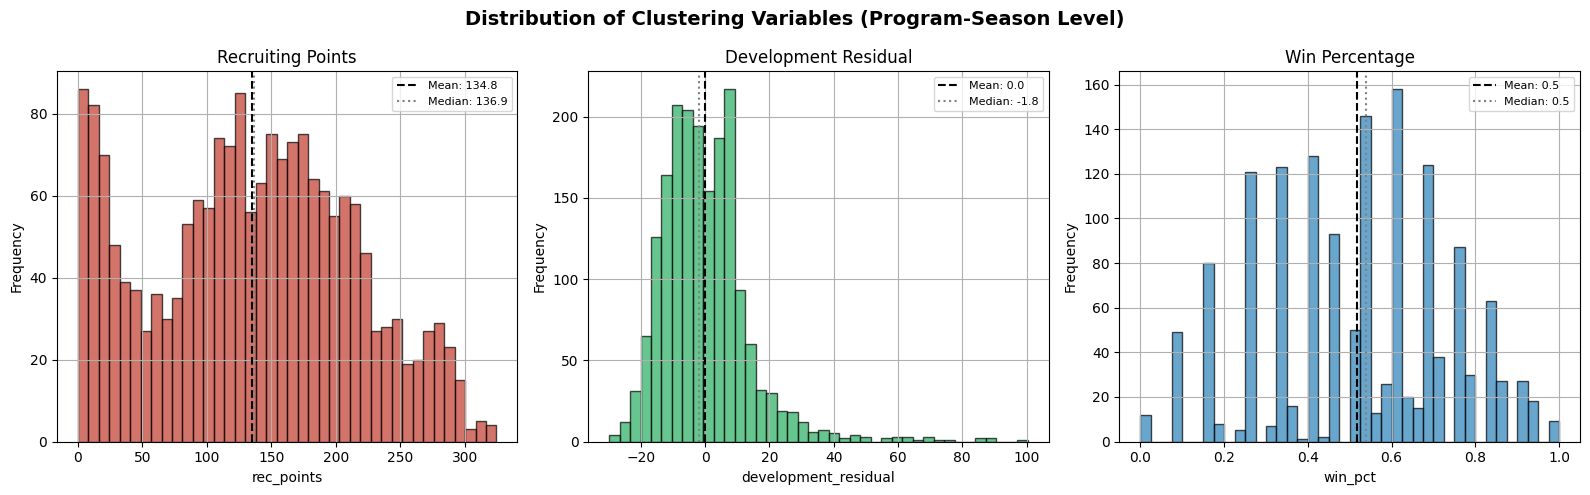

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Distribution of Clustering Variables (Program-Season Level)",
             fontsize=14, fontweight="bold")

variables = ["rec_points", "development_residual", "win_pct"]
titles = ["Recruiting Points", "Development Residual", "Win Percentage"]
colors = ["#c0392b", "#27ae60", "#2980b9"]

for ax, var, title, color in zip(axes, variables, titles, colors):
    complete[var].dropna().hist(bins=40, ax=ax, color=color, 
                                edgecolor="black", alpha=0.7)
    ax.axvline(complete[var].mean(), color="black", linestyle="--", 
               linewidth=1.5, label=f"Mean: {complete[var].mean():.1f}")
    ax.axvline(complete[var].median(), color="gray", linestyle=":",
               linewidth=1.5, label=f"Median: {complete[var].median():.1f}")
    ax.set_title(title, fontsize=12)
    ax.set_xlabel(var)
    ax.set_ylabel("Frequency")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

All 3 distributions are acceptable for the clustering that I'm going to do in the next phase.

# Clustering

I want to understand if there are specific clusters that programs fit into. Across college football media and literature, there is a consensus that there are certain archetypes for programs. Want to understand if the data confirms this

In [ ]:
# aggregate to program level
program_level = (complete.groupby("team")
                 .agg(
                     avg_rec_points=("rec_points", "mean"),
                     avg_dev_residual=("development_residual", "mean"),
                     avg_win_pct=("win_pct", "mean"),
                     seasons=("year", "count")
                 )
                 .query("seasons >= 5")
                 .reset_index())

print(f"Programs with 5+ seasons: {program_level.shape[0]}")
print(program_level.describe().round(2))

# scale features
features = ["avg_rec_points", "avg_dev_residual", "avg_win_pct"]
X = program_level[features].dropna()
programs_clean = program_level.loc[X.index].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# test k=2 through k=8
print("\n=== silhoutte scores ===")
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    inertia = km.inertia_
    print(f"  k={k}: silhouette={sil:.3f}, inertia={inertia:.1f}")

Programs with 5+ seasons: 169
       avg_rec_points  avg_dev_residual  avg_win_pct  seasons
count          169.00            169.00       129.00   169.00
mean           126.52              0.28         0.51    10.20
std             75.81             10.14         0.15     3.21
min              8.40            -15.97         0.17     5.00
25%             73.13             -6.87         0.40     6.00
50%            119.12             -2.26         0.53    12.00
75%            184.25              5.74         0.61    12.00
max            285.03             65.06         0.85    14.00

=== SILHOUETTE SCORES BY K ===
  k=2: silhouette=0.436, inertia=211.3
  k=3: silhouette=0.379, inertia=148.3
  k=4: silhouette=0.317, inertia=114.3
  k=5: silhouette=0.351, inertia=89.0
  k=6: silhouette=0.349, inertia=73.1
  k=7: silhouette=0.355, inertia=61.9
  k=8: silhouette=0.320, inertia=55.3


GMM clustering

In [ ]:

print("GMM silhoutte scores")
for n in range(2, 9):
    gmm = GaussianMixture(n_components=n, random_state=42, n_init=10)
    labels = gmm.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    bic = gmm.bic(X_scaled)
    aic = gmm.aic(X_scaled)
    print(f"  n={n}: silhouette={sil:.3f}, BIC={bic:.1f}, AIC={aic:.1f}")

=== GMM SILHOUETTE SCORES BY N COMPONENTS ===
  n=2: silhouette=0.416, BIC=928.7, AIC=874.3
  n=3: silhouette=0.249, BIC=924.5, AIC=841.6
  n=4: silhouette=0.236, BIC=939.7, AIC=828.2
  n=5: silhouette=0.219, BIC=952.9, AIC=812.7
  n=6: silhouette=0.212, BIC=954.9, AIC=786.1
  n=7: silhouette=0.205, BIC=960.7, AIC=763.3
  n=8: silhouette=0.179, BIC=1004.0, AIC=778.0


DBSCAN

In [ ]:
print("dbscan parameter search")


for eps in [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 1.0, 1.2]:
    for min_samples in [3, 4, 5]:
        db = DBSCAN(eps=eps, min_samples=min_samples)
        labels = db.fit_predict(X_scaled)
        
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = (labels == -1).sum()
        
        # Only compute silhouette if more than 1 cluster and not all noise
        if n_clusters > 1 and n_noise < len(labels) - 1:
            sil = silhouette_score(X_scaled, labels)
            print(f"{eps:>6} {min_samples:>12} {n_clusters:>12} {n_noise:>10} {sil:>12.3f}")
        else:
            print(f"{eps:>6} {min_samples:>12} {n_clusters:>12} {n_noise:>10} {'N/A':>12}")

=== DBSCAN PARAMETER SEARCH ===
   eps  min_samples   n_clusters    n_noise   silhouette
-------------------------------------------------------
   0.3            3            6         76       -0.037
   0.3            4            5         87       -0.135
   0.3            5            2        102       -0.055
   0.4            3            6         39        0.026
   0.4            4            5         57        0.012
   0.4            5            3         71       -0.024
   0.5            3            4         24        0.084
   0.5            4            2         37        0.092
   0.5            5            4         48       -0.055
   0.6            3            3         14        0.179
   0.6            4            3         14        0.179
   0.6            5            2         24        0.145
   0.7            3            2          8        0.387
   0.7            4            2         10        0.381
   0.7            5            1         15          N/A


All three clustering algorithms found that college football programs don't fall into clear discrete buckets.

Tested k-means, GMM, and DBSCAN clustering and no algorithm produced well separated, interpretable cluster. This suggests that program archetypes in college football exist as a continuous spectrum rather than discrete categories.

## Program Trajectory Clustering:

For each program, I am fitting a linear trend line across years for each of the three key variables and using the slopes as the clustering features. 

In [ ]:
trajectory_rows = []

for team, group in complete.groupby("team"):
    group = group.sort_values("year")
    
    if len(group) < 5:
        continue
    
    years = group["year"].values
    
    # fit linear trend for each variable
    rec_slope, _, rec_r, _, _ = stats.linregress(years, group["rec_points"].values)
    win_slope, _, win_r, _, _ = stats.linregress(years, group["win_pct"].values)
    dev_slope, _, dev_r, _, _ = stats.linregress(years, group["development_residual"].values)
    
    trajectory_rows.append({
        "team": team,
        "rec_slope": rec_slope,
        "win_slope": win_slope,
        "dev_slope": dev_slope,
        "rec_r": rec_r,
        "win_r": win_r,
        "dev_r": dev_r,
        "n_seasons": len(group),
        "avg_rec_points": group["rec_points"].mean(),
        "avg_win_pct": group["win_pct"].mean(),
        "avg_dev_residual": group["development_residual"].mean(),
    })

traj_df = pd.DataFrame(trajectory_rows)

print(f"Programs with 5+ seasons: {traj_df.shape[0]}")
print()
print("slope distributions")
print(traj_df[["rec_slope", "win_slope", "dev_slope"]].describe().round(4))
print()

# check: Alabama should have improving trends
print("sample programs")
sample = ["Alabama", "Nebraska", "Georgia", "Tennessee", "Iowa"]
print(traj_df[traj_df["team"].isin(sample)]
      [["team", "rec_slope", "win_slope", "dev_slope"]]
      .round(4).to_string())

Programs with 5+ seasons: 169

=== slope distributions ===
       rec_slope  win_slope  dev_slope
count   169.0000   119.0000   169.0000
mean      4.5564     0.0016    -0.7881
std       5.4899     0.0230     1.6793
min      -3.3062    -0.0584    -5.6031
25%       1.2578    -0.0141    -1.7300
50%       3.4348     0.0020    -0.7654
75%       6.8843     0.0146     0.0870
max      26.1951     0.0886     6.1011

=== sample programs ===
          team  rec_slope  win_slope  dev_slope
2      Alabama     8.4280     0.0261     5.6272
41     Georgia     1.1256    -0.0046     1.2509
52        Iowa    -3.1632     0.0076     0.0870
82    Nebraska    -1.1712     0.0019    -2.5470
128  Tennessee     1.6729     0.0022    -2.5180


In [ ]:
# use slopes as clustering features
traj_features = ["rec_slope", "win_slope", "dev_slope"]
X_traj = traj_df[traj_features].dropna()
traj_clean = traj_df.loc[X_traj.index].copy()

scaler_traj = StandardScaler()
X_traj_scaled = scaler_traj.fit_transform(X_traj)

print("kmeans ilhoutte scores")
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_traj_scaled)
    sil = silhouette_score(X_traj_scaled, labels)
    inertia = km.inertia_
    print(f"  k={k}: silhouette={sil:.3f}, inertia={inertia:.1f}")

print()
print("GMM scores")
for n in range(2, 9):
    gmm = GaussianMixture(n_components=n, random_state=42, n_init=10)
    labels = gmm.fit_predict(X_traj_scaled)
    sil = silhouette_score(X_traj_scaled, labels)
    bic = gmm.bic(X_traj_scaled)
    aic = gmm.aic(X_traj_scaled)
    print(f"  n={n}: silhouette={sil:.3f}, BIC={bic:.1f}, AIC={aic:.1f}")

=== KMEANS SILHOUETTE SCORES ===
  k=2: silhouette=0.263, inertia=251.8
  k=3: silhouette=0.281, inertia=201.8
  k=4: silhouette=0.237, inertia=170.9
  k=5: silhouette=0.257, inertia=143.3
  k=6: silhouette=0.231, inertia=126.3
  k=7: silhouette=0.250, inertia=112.3
  k=8: silhouette=0.274, inertia=98.0

=== GMM BIC/AIC SCORES ===
  n=2: silhouette=0.277, BIC=1049.4, AIC=996.6
  n=3: silhouette=0.093, BIC=1033.2, AIC=952.6
  n=4: silhouette=0.074, BIC=1057.2, AIC=948.9
  n=5: silhouette=0.056, BIC=1056.3, AIC=920.1
  n=6: silhouette=0.123, BIC=1110.3, AIC=946.4
  n=7: silhouette=0.135, BIC=1131.2, AIC=939.4
  n=8: silhouette=0.020, BIC=1100.7, AIC=881.2


This also shows that clustering college football programs is ineffective. Programs exist on a continuous spectrum and forcing them into buckets would misrepresent them.

## Coach Level Development

In [ ]:
coach_dev = (complete.groupby("coach_name")
             .agg(
                 avg_dev_residual=("development_residual", "mean"),
                 avg_rec_points=("rec_points", "mean"),
                 avg_win_pct=("win_pct", "mean"),
                 seasons=("year", "count")
             )
             .query("seasons >= 4")
             .sort_values("avg_dev_residual", ascending=False)
             .reset_index())

print("Top 15 coaches by development residual")
print(coach_dev.head(15).round(2).to_string())
print()
print("Bottom 15 coaches by development residual")
print(coach_dev.tail(15).round(2).to_string())

=== TOP 15 COACHES BY DEVELOPMENT RESIDUAL ===
        coach_name  avg_dev_residual  avg_rec_points  avg_win_pct  seasons
0       Nick Saban             71.53          297.02         0.86       10
1      Urban Meyer             43.89          287.68         0.85       11
2        Les Miles             35.67          273.01         0.77       12
3     Pete Carroll             31.33          295.35         0.85        5
4     Dabo Swinney             27.75          249.80         0.74        9
5    Will Muschamp             27.75          264.91         0.55        5
6     Jim Harbaugh             23.11          211.64         0.64        6
7      Butch Davis             20.36          233.16         0.54        4
8      Jim Tressel             16.18          204.68         0.86        6
9       Bob Stoops             16.09          257.09         0.77       12
10    Jimbo Fisher             15.79          284.27         0.82        7
11    Mike Sherman             15.34          220.61 

Interesting Notes:

Top Developer List
- Nick Saban at +71.53: nearly double Urban Meyer's. Best developer by a massive margin
- Will Muschamp at +27.75 with only .55 win pct, and Ed Orgeron with +13.22 with .45 win pct: Develop NFL talent at an elite rate but struggle to wins games. Building NFL factory without the program success.
- Chris Petersen at +14.89 with only 161 recruiting points: develops players way beyond their recruiting ranking with modest talent

Bottom developers list:
- Butch Jones at -13.15
- Rich Rodriguez at -15.84: recruits well (205 points), but terrible development. Modest win pct at 60%
- Butch Jones at -13.15 but 63 win pct.

## Position Level Draft Analysis

In [ ]:
# for each position find the top 3 programs by total picks
position_leaders = (draft[draft["draft_year"] >= 2010]
                    .groupby(["school_std", "position"])
                    .agg(total_picks=("player_name", "count"))
                    .reset_index())

# filter to positions with meaningful sample sizes (very few punters/kickers will be drafted)
position_counts = position_leaders.groupby("position")["total_picks"].sum()
meaningful_positions = position_counts[position_counts >= 20].index
position_leaders = position_leaders[
    position_leaders["position"].isin(meaningful_positions)
]

print("toip 3 programs by poisiton (2010-2021)")
for pos, group in position_leaders.groupby("position"):
    top3 = group.nlargest(3, "total_picks")[["school_std", "total_picks"]]
    print(f"\n{pos}:")
    for _, row in top3.iterrows():
        print(f"  {row['school_std']:<25} {int(row['total_picks'])} picks")

=== TOP 3 PROGRAMS BY POSITION (2010-2021) ===

Center:
  Alabama                   3 picks
  Michigan                  3 picks
  Ohio State                3 picks

Cornerback:
  LSU                       12 picks
  Alabama                   11 picks
  Ohio State                11 picks

Defensive End:
  Ohio State                11 picks
  Miami                     9 picks
  Clemson                   8 picks

Defensive Tackle:
  Alabama                   14 picks
  Auburn                    8 picks
  LSU                       8 picks

Fullback:
  Auburn                    2 picks
  Northwestern              2 picks
  Oklahoma                  2 picks

Inside Linebacker:
  Alabama                   9 picks
  LSU                       8 picks
  Georgia                   5 picks

Offensive Guard:
  Alabama                   6 picks
  Georgia                   5 picks
  Miami                     5 picks

Offensive Tackle:
  Oklahoma                  8 picks
  Alabama                   7 p

- Alabama appears in nearly ever position's top 3

Position Specialization:
- Stanford/Notre Dame own Tight End development
- LSU owns cornerback and wide receiver development
- Miami appears in defensive end (2nd), offensive guard (3rd), and Tight End (3rd) despite not being a dominant program in development residual rankings. They produce NFL talent at specific positions despite inconsistent winning